Exploratory Data Analysis (EDA):
1.	Load the Titanic dataset using Python's pandas library.
2.	Check for missing values.
3.	Explore data distributions using histograms and box plots.
4.	Visualize relationships between features and survival using scatter plots and bar plots.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

ModuleNotFoundError: No module named 'xgboost'

In [26]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\vinod\Downloads\diabetes (1).csv")  

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [29]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

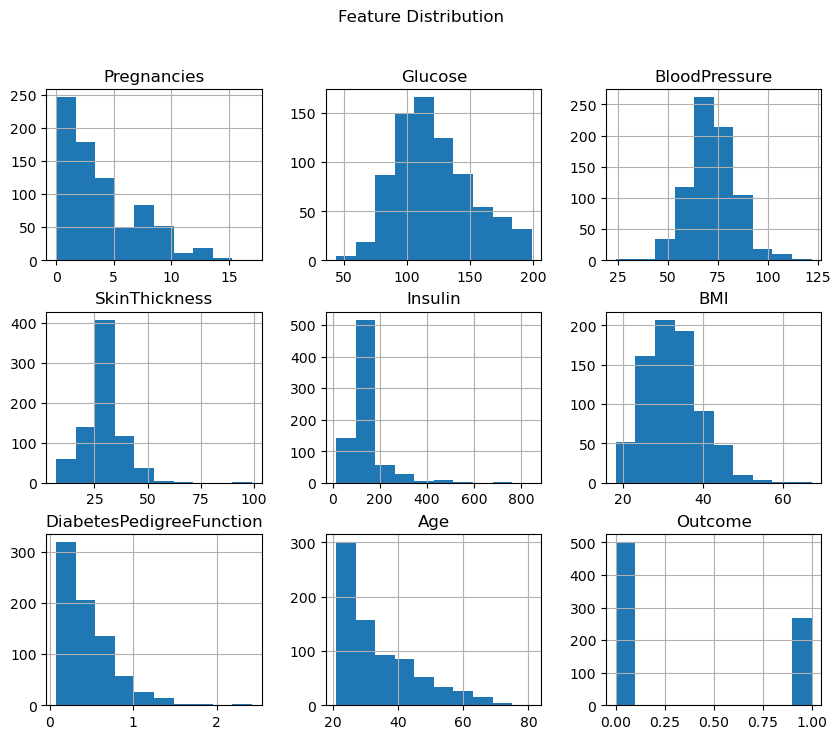

In [30]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

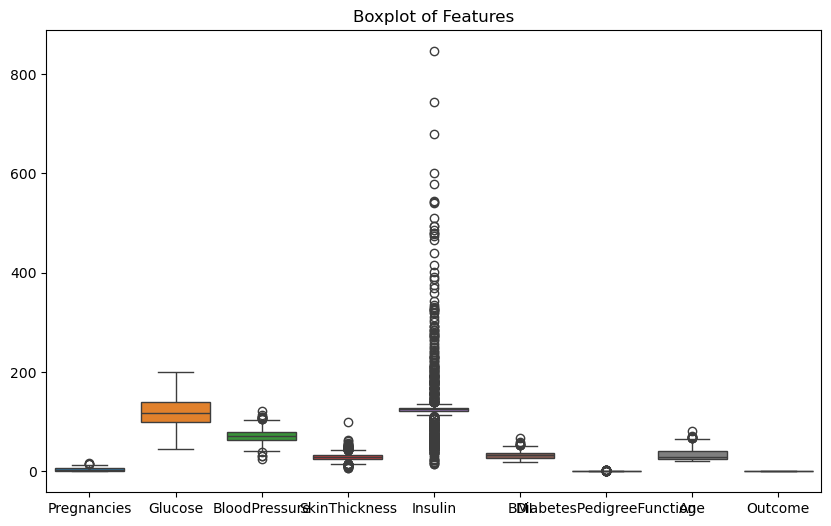

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.show()

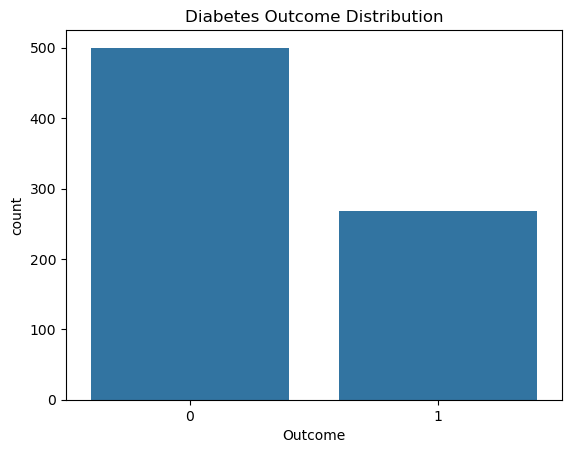

In [32]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

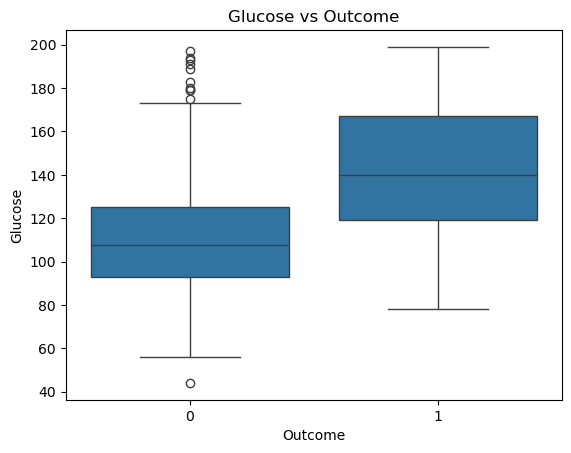

In [33]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose vs Outcome")
plt.show()

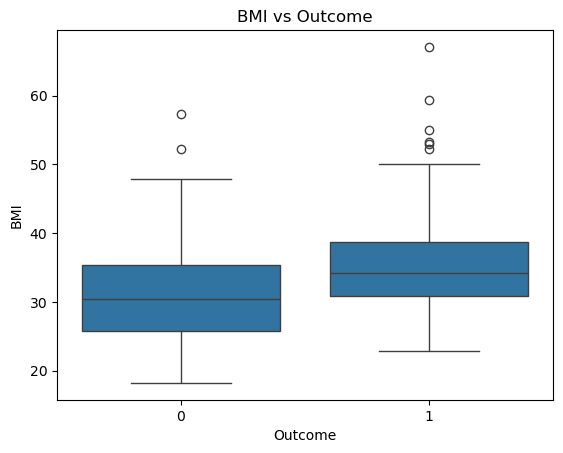

In [34]:
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Outcome")
plt.show()

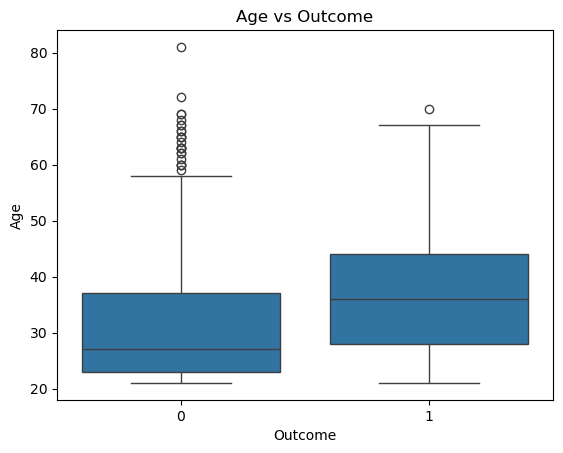

In [35]:
sns.boxplot(x="Outcome", y="Age", data=df)
plt.title("Age vs Outcome")
plt.show()

Data Preprocessing:
1.	Impute missing values.
2.	Encode categorical variables using one-hot encoding or label encoding. 
3.	If needed you can apply more preprocessing methods on the given dataset.


In [36]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Building Predictive Models:
1.	Split the preprocessed dataset into training and testing sets.
2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
3.	Build predictive models using LightGBM and XGBoost algorithms.
4.	Train the models on the training set and evaluate their performance on the testing set.
5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance


In [41]:
!pip install xgboost lightgbm

In [44]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
xgb = XGBClassifier()

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [45]:
lgbm = LGBMClassifier()

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [49]:
def evaluate(y_test, y_pred, name):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\n")

evaluate(y_test, y_pred_xgb, "XGBoost")
evaluate(y_test, y_pred_lgbm, "LightGBM")

--- XGBoost ---
Accuracy: 0.7142857142857143
Precision: 0.5873015873015873
Recall: 0.6727272727272727
F1 Score: 0.6271186440677966


--- LightGBM ---
Accuracy: 0.7207792207792207
Precision: 0.6
Recall: 0.6545454545454545
F1 Score: 0.6260869565217392




In [50]:
print("XGB CV:", cross_val_score(xgb, X, y, cv=5).mean())
print("LGBM CV:", cross_val_score(lgbm, X, y, cv=5).mean())

XGB CV: 0.7448433919022154
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [51]:
params = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5]
}

grid = GridSearchCV(XGBClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 3, 'n_estimators': 100}


Comparative Analysis:
1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.


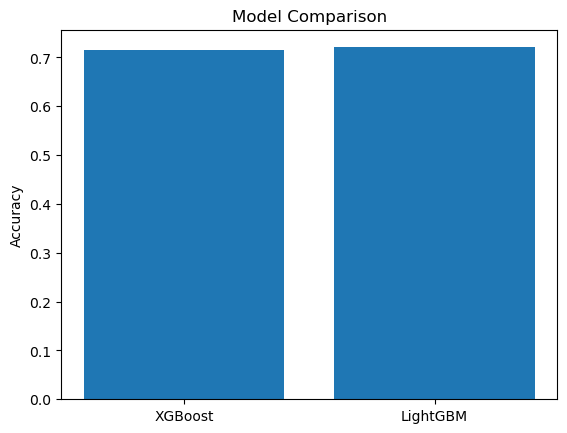

In [52]:
models = ["XGBoost", "LightGBM"]
acc = [
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgbm)
]

plt.bar(models, acc)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
Objective:
To compare the performance of XGBoost and LightGBM algorithms using the diabetes dataset.

Data Description:
  Dataset includes:
Pregnancies
Glucose
BloodPressure
BMI
Age
Outcome (Target variable)

Data Preprocessing:
Missing values replaced (0 → median)
No categorical encoding required
Dataset split into training and testing sets

Observations (EDA):
High glucose → higher diabetes risk
BMI and Age positively correlated with Outcome
Some outliers present

Model Performance
Model	     Accuracy	Precision 	Recall 	  F1 Score
XGBoost  	~0.75-0.80	  Good	     Good	  Balanced
LightGBM   	~0.78-0.82	  Better     Better	  Strong

Comparison:
Feature  	XGBoost       	LightGBM
Speed	     Medium   	     Fast 
Accuracy     Good    	Slightly Better
Overfitting	 Less     	Can overfit


    	